# Tujuan, Hipotesis, dan Data

1. Tujuan:
* Mencari hubungan antara suhu dengan kelembaban
* Mencari arah dan besar hubungan tersebut

2. Hipotesis:
* H0 = Tidak ada hubungan antara suhu dan kelembaban
* H1 = Ada hubungan antara suhu dan kelembaban

3. Data:
* Data didapatkan dari Data Online BMKG (https://dataonline.bmkg.go.id/) pada stasiun Halim Perdana Kusuma, Jakarta Timur dengan mengambil data TAvg (suhu rata-rata) dan RH_Avg (kelembaban relatif rata-rata) dari tanggal 01 Januari 2026 sampai 31 Maret 2026.

# Import dan Load

In [9]:
import pandas as pd
import numpy as np

import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import probplot, shapiro, pearsonr, spearmanr

In [10]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [4]:
df_halim = pd.read_excel('BMKG-Halim-Cuaca.xlsx')

In [5]:
df_halim.sample(5)

,TANGGAL,TAVG,RH_AVG
65,07-03-2026,25.1,93
56,26-02-2026,28.7,47
51,21-02-2026,27.6,70
82,24-03-2026,27.6,77
62,04-03-2026,26.1,81


# Eksplorasi dan Visualisasi Awal

Visualisasi Scatter Plot langsung untuk melihat persebaran dan tren dari kedua data tersebut. Dapat dilihat data memiliki tren negatif dan cenderung bisa dekat garis regresi (kalau seandainya pakai regresi)

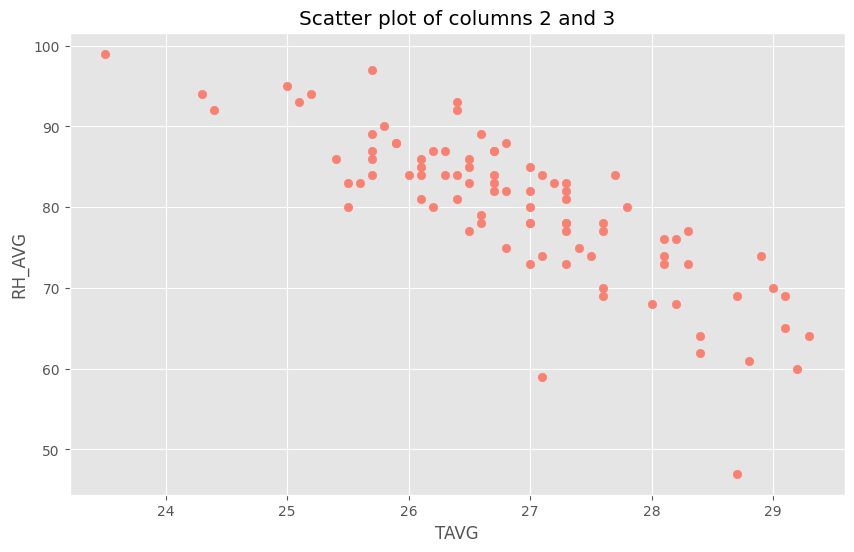

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df_halim.iloc[:, 1:].values[:, 0], df_halim.iloc[:, 1:].values[:, 1], color='salmon') # Assuming two columns after the first one for x and y
plt.xlabel(df_halim.columns[1]) # Use the name of the second column for x-axis label
plt.ylabel(df_halim.columns[2]) # Use the name of the third column for y-axis label
plt.title('Scatter plot of columns 2 and 3')
plt.show()


Visualisasi untuk distribusi. Cenderung membentuk lonceng, walaupun tidak benar-benar normal sempurna.

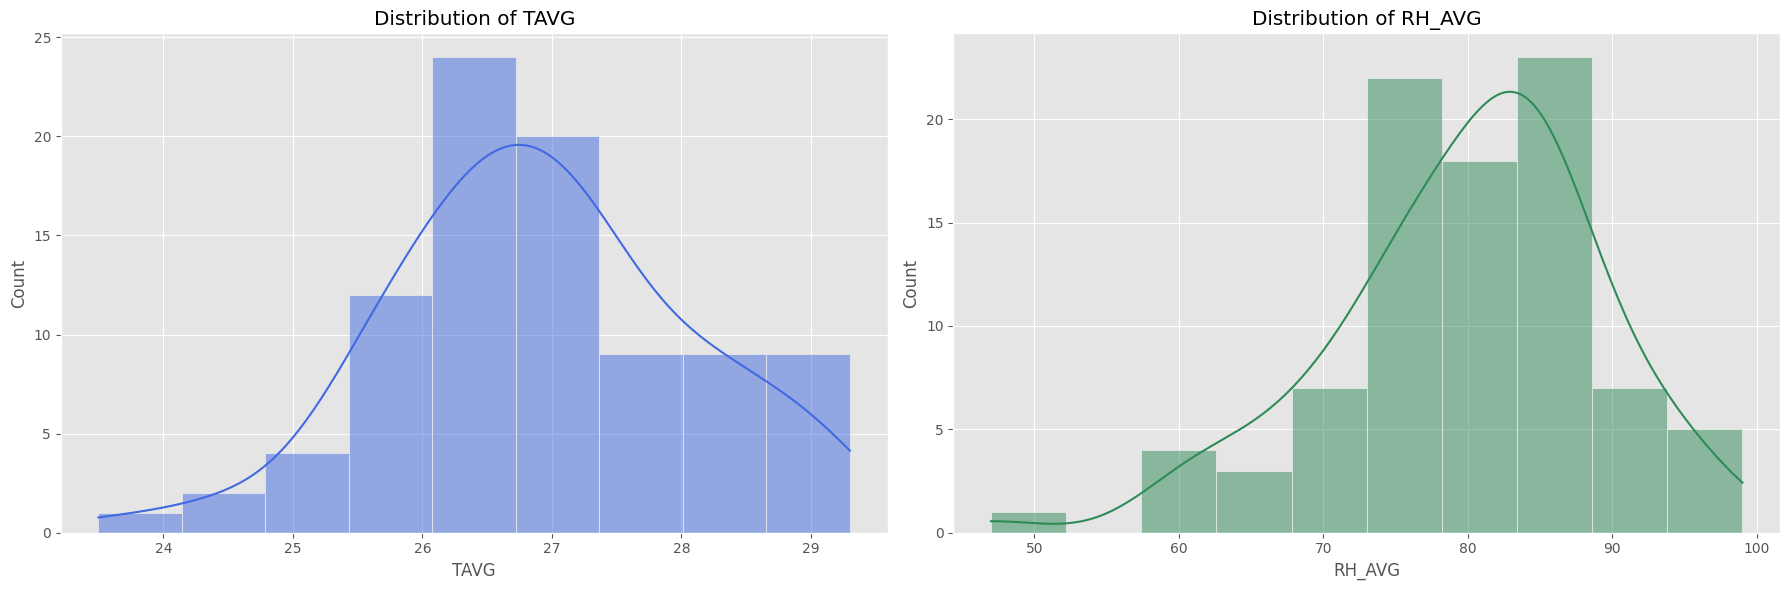

In [8]:
# Set up the figure for Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribution for TAVG
sns.histplot(df_halim['TAVG'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of TAVG')

# Distribution for RH_AVG
sns.histplot(df_halim['RH_AVG'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of RH_AVG')

plt.tight_layout()
plt.show()

Visualisasi Q-Q Plot

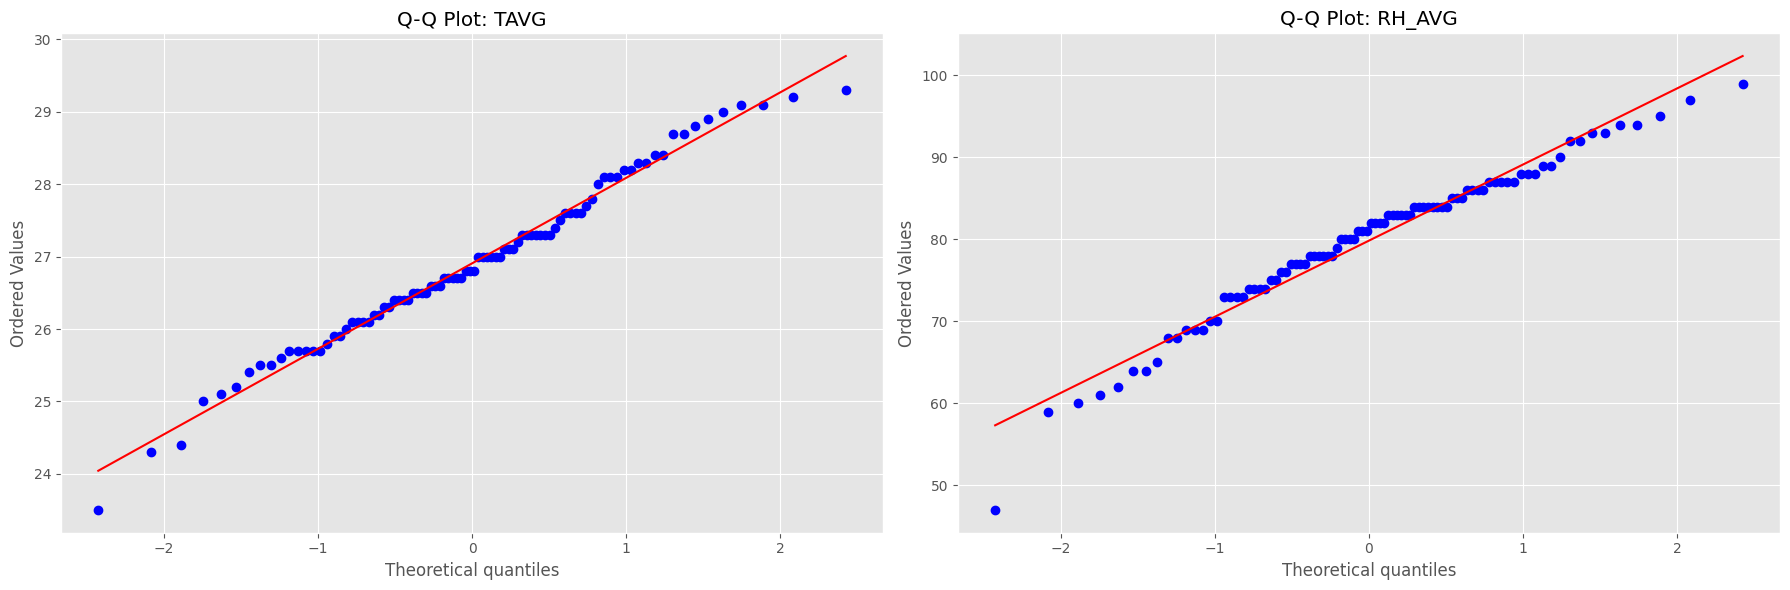

In [11]:
plt.figure(figsize=(18, 6))

# Q-Q plot for TAVG
plt.subplot(1, 2, 1)
probplot(df_halim['TAVG'], dist="norm", plot=plt)
plt.title('Q-Q Plot: TAVG')

# Q-Q plot for RH_AVG
plt.subplot(1, 2, 2)
probplot(df_halim['RH_AVG'], dist="norm", plot=plt)
plt.title('Q-Q Plot: RH_AVG')

plt.tight_layout()
plt.show()

Tabel Korelasi Pearson secara langsung

In [12]:
df_halim.iloc[:, 1:].corr(method="pearson")

,TAVG,RH_AVG
TAVG,1.000000,-0.820466
RH_AVG,-0.820466,1.000000


# Uji Asumsi Klasik

Uji Linieritas, Homoskedastisitas, dan Deteksi Outlier dinilai sudah lolos karena hasil visualisasi dari tahap sebelumnya dinilai baik.

Jika seandainya salah satu dari ketiga itu ada yang tidak terpenuhi:
*   Jika Outlier sedikit, maka buang data outlier
*   Jika Outlier banyak, maka pakai Uji Korelasi Spearman atau Kendall's Tau
*   Jika tidak Linier tapi membentuk pola lain, maka pakai Uji Korelasi Spearman atau Kendall's Tau
*   Jika Heteroskedastisitas kuat, maka pakai Statsmodels dan gunakan Robust Standard Error dengan contoh

```python
import statsmodels.api as sm

X = sm.add_constant(df['X'])
model = sm.OLS(df['Y'], X).fit(cov_type='HC3')
```

*   Jika persebaran benar-benar acak, maka tidak bisa pakai Uji Korelasi

Berikut Uji Normalitas

In [13]:
# Uji Normalitas (Shapiro-Wilk)
stat_x, p_x = shapiro(df_halim['TAVG'])
stat_y, p_y = shapiro(df_halim['RH_AVG'])

print(f"Normalitas TAVG: p={p_x:.4f}")
print(f"Normalitas RH_AVG: p={p_y:.4f}")

# Jika p < 0.05, pertimbangkan korelasi Spearman

Normalitas TAVG: p=0.4776
Normalitas RH_AVG: p=0.0260


* Nilai normalitas RH_AVG di bawah 0.05, yang berarti tidak normal. Oleh karena itu menggunakan korelasi Spearman.
* Jika seandainya kedua variabel lolos uji normalitas, maka bisa pakai korelasi Pearson

# Uji Hipotesis

Nilai r (korelasi) dan p_value (signifikansi)

In [14]:
# Menghitung Korelasi Spearman dan P-Value
r, p_value = spearmanr(df_halim['TAVG'], df_halim['RH_AVG'])

print(f"Koefisien Korelasi (r): {r:.4f}")
print(f"Signifikansi (p-value): {p_value:.4e}")

# Interpretasi
if p_value < 0.05:
    print("Kesimpulan: Hubungan Signifikan secara statistik.")
else:
    print("Kesimpulan: Hubungan Tidak Signifikan.")

Koefisien Korelasi (r): -0.8310
Signifikansi (p-value): 3.9431e-24
Kesimpulan: Hubungan Signifikan secara statistik.


Nilai R2, untuk analisis lebih lanjut saja, bukan prioritas

In [15]:
r_squared = r**2
print(f"Koefisien Determinasi (R^2): {r_squared:.4f}")
print(f"Artinya: {r_squared*100:.2f}% variasi RH_AVG dijelaskan oleh T_AVG")

Koefisien Determinasi (R^2): 0.6905
Artinya: 69.05% variasi RH_AVG dijelaskan oleh T_AVG


# Jawaban

* Karena nilai signifikansi (p_value) sangat kecil atau kurang dari 0.05, maka kita menolak H0 (tidak ada hubungan) dan menerima H1 (ada hubungan).
* Hubungan antara kedua variabel adalah negatif, jadi jika Suhu naik, maka kelembaban akan turun, dan begitu juga sebaliknya. Nilai kekuatan tersebut adalah 0.83, yang berarti berhubungan kuat.
* R2 sebagai tambahan informasi yang telah dijelaskan pada bagian sebelumnya
